In [12]:
include(joinpath(@__DIR__, "..", "readclassjson.jl"))
using LinearAlgebra
using Plots

In [13]:
data = readclassjson("bs_det_data.json")
Y = data["Y"]

T = data["T"]
R = Y * Y' / T

eigDecomp = eigen(R)

maxEigValIdx = argmax(eigDecomp.values)
mu = eigDecomp.values[maxEigValIdx]
w_scaled = eigDecomp.vectors[:,maxEigValIdx]

w = w_scaled / (norm(w_scaled) * sqrt(mu))

println("Weight vector w is:")
display(w)

Weight vector w is:


20-element Vector{Float64}:
  0.03224530108439295
  0.09600678070245433
 -0.01230037669634649
 -0.01986756385864364
  0.06334718004403024
 -0.06626859793252056
 -0.07769274840286251
  0.003748387075843225
 -0.016515994508527317
 -0.012568547850148515
  0.013991403119214398
 -0.03722671802828627
  0.03154105297560478
 -0.12525945464545404
  0.01370022405055513
 -0.01046626044477991
 -0.06061734279257342
 -0.010108430511189828
  0.00920813881835035
  0.04747941079048277

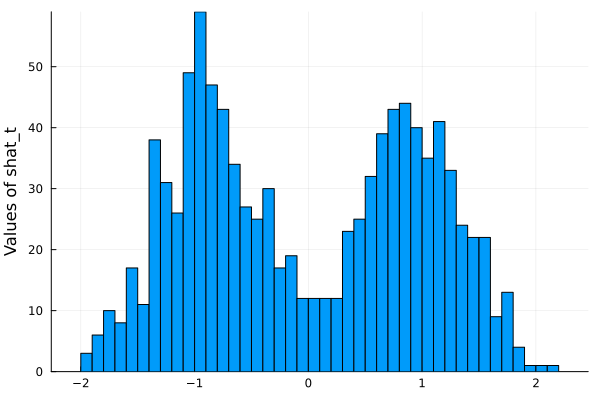

In [14]:
shat = w'*Y
histogram(shat[:], bins=60, legend=false, xlabel="", ylabel="Values of shat_t")

### Error rate

In [ ]:
signs = data["s"]

errors = 0
for t in 1:T
    shat_t = -w' * Y[:,t] # flipped sign due to error rate majority for positive
    if (shat_t >= 0 && signs[t] == -1) || (shat_t < 0 && signs[t] == 1)
        errors += 1
    end
end

error_rate = errors / T
println("Error rate is $error_rate")

Error rate is 0.029
